<a href="https://colab.research.google.com/github/Kishan-kp-ai/Linkific-Tasks/blob/main/Day%2014/SpamHamMLmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 records:
  label                                            message
0   ham                 Hey, are we meeting today at 6 PM?
1   ham                 Please send me the project report.
2  spam  Congratulations! You have won a free prize. Cl...
3   ham               Can you call me when you reach home?
4  spam      URGENT! You have won a cash reward. Call now!

Dataset shape: (30, 2)

Missing values:
label      0
message    0
dtype: int64

Duplicate records: 0

Label distribution:
label
ham     18
spam    12
Name: count, dtype: int64

Dataset after cleaning:
Total records: 30
Missing values: 0
Duplicate records: 0


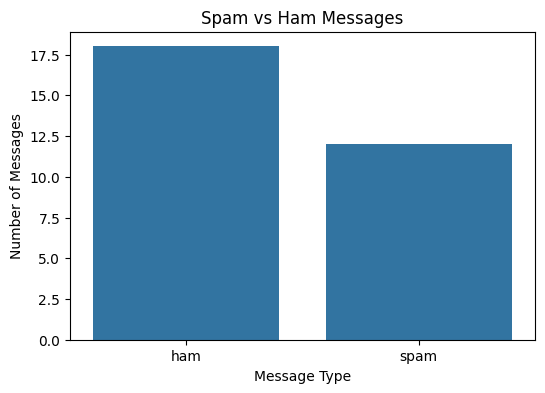


Numerical labels:
label
0    18
1    12
Name: count, dtype: int64

Total messages: 30

Training messages: 24
Testing messages: 6

TF-IDF Vectorization completed.
Training TF-IDF shape: (24, 70)
Testing TF-IDF shape: (6, 70)

Logistic Regression training completed.

Predictions completed.

MODEL EVALUATION
Accuracy : 83.33 %
Precision: 66.67 %
Recall   : 100.0 %
F1 Score : 80.0 %

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         Ham       1.00      0.75      0.86         4
        Spam       0.67      1.00      0.80         2

    accuracy                           0.83         6
   macro avg       0.83      0.88      0.83         6
weighted avg       0.89      0.83      0.84         6


CONFUSION MATRIX
[[3 1]
 [0 2]]


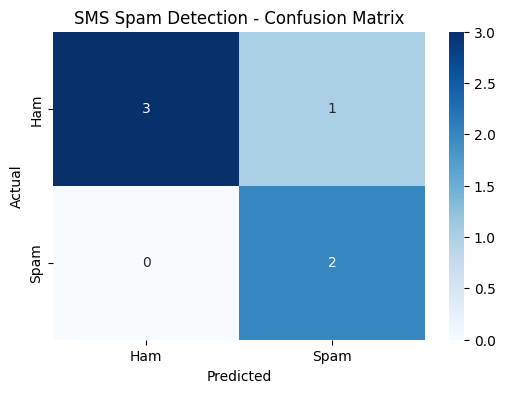


NEW MESSAGE PREDICTIONS

Message: Congratulations! You have won a free prize. Claim now!
Prediction: SPAM

Message: Hi, are we meeting today at 6 PM?
Prediction: HAM

Message: URGENT! You have won a cash reward. Call now!
Prediction: SPAM

Message: Please send me the project report.
Prediction: HAM

PROJECT SUMMARY
Dataset records: 30
Training records: 24
Testing records: 6
Model: Logistic Regression
Feature Extraction: TF-IDF
Accuracy: 83.33 %
Precision: 66.67 %
Recall: 100.0 %
F1 Score: 80.0 %


In [ ]:

# Install required libraries
!pip install pandas scikit-learn nltk matplotlib seaborn -q

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("/content/sms_spam_dataset.csv")

print("First 5 records:")
print(df.head())

print("\nDataset shape:", df.shape)

# ============================================================
# 2. CHECK DATA
# ============================================================

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate records:", df.duplicated().sum())

print("\nLabel distribution:")
print(df["label"].value_counts())

# ============================================================
# 3. CLEAN DATA
# ============================================================

# Remove missing values
df = df.dropna()

# Remove duplicate records
df = df.drop_duplicates()

# Reset index
df = df.reset_index(drop=True)

# Convert messages to lowercase
df["message"] = df["message"].str.lower()

print("\nDataset after cleaning:")
print("Total records:", len(df))
print("Missing values:", df.isnull().sum().sum())
print("Duplicate records:", df.duplicated().sum())

# ============================================================
# 4. VISUALIZE SPAM / HAM DISTRIBUTION
# ============================================================

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

# ============================================================
# 5. CONVERT LABELS TO NUMBERS
# ============================================================

# ham = 0
# spam = 1

df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print("\nNumerical labels:")
print(df["label"].value_counts())

# ============================================================
# 6. DEFINE FEATURES AND TARGET
# ============================================================

X = df["message"]
y = df["label"]

print("\nTotal messages:", len(X))

# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining messages:", len(X_train))
print("Testing messages:", len(X_test))

# ============================================================
# 8. TF-IDF VECTORIZATION
# ============================================================

vectorizer = TfidfVectorizer(
    stop_words="english"
)

# Learn vocabulary from training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform test data
X_test_tfidf = vectorizer.transform(X_test)

print("\nTF-IDF Vectorization completed.")

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

# ============================================================
# 9. TRAIN LOGISTIC REGRESSION
# ============================================================

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_tfidf,
    y_train
)

print("\nLogistic Regression training completed.")

# ============================================================
# 10. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test_tfidf)

print("\nPredictions completed.")

# ============================================================
# 11. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("\n================================")
print("MODEL EVALUATION")
print("================================")

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")

# ============================================================
# 12. CLASSIFICATION REPORT
# ============================================================

print("\n================================")
print("CLASSIFICATION REPORT")
print("================================")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"],
        zero_division=0
    )
)

# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n================================")
print("CONFUSION MATRIX")
print("================================")

print(cm)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("SMS Spam Detection - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================================
# 14. TEST NEW MESSAGES
# ============================================================

new_messages = [
    "Congratulations! You have won a free prize. Claim now!",
    "Hi, are we meeting today at 6 PM?",
    "URGENT! You have won a cash reward. Call now!",
    "Please send me the project report."
]

# Convert new messages into TF-IDF
new_messages_tfidf = vectorizer.transform(new_messages)

# Predict
new_predictions = model.predict(new_messages_tfidf)

print("\n================================")
print("NEW MESSAGE PREDICTIONS")
print("================================")

for message, prediction in zip(
    new_messages,
    new_predictions
):

    result = "SPAM" if prediction == 1 else "HAM"

    print("\nMessage:", message)
    print("Prediction:", result)

# ============================================================
# 15. FINAL SUMMARY
# ============================================================

print("\n================================")
print("PROJECT SUMMARY")
print("================================")

print("Dataset records:", len(df))
print("Training records:", len(X_train))
print("Testing records:", len(X_test))
print("Model: Logistic Regression")
print("Feature Extraction: TF-IDF")
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall:", round(recall * 100, 2), "%")
print("F1 Score:", round(f1 * 100, 2), "%")